🎤 Recording for 5 seconds... Speak now!
✅ Recording complete!
This is your voice
Mel Spectogram
Spectogram


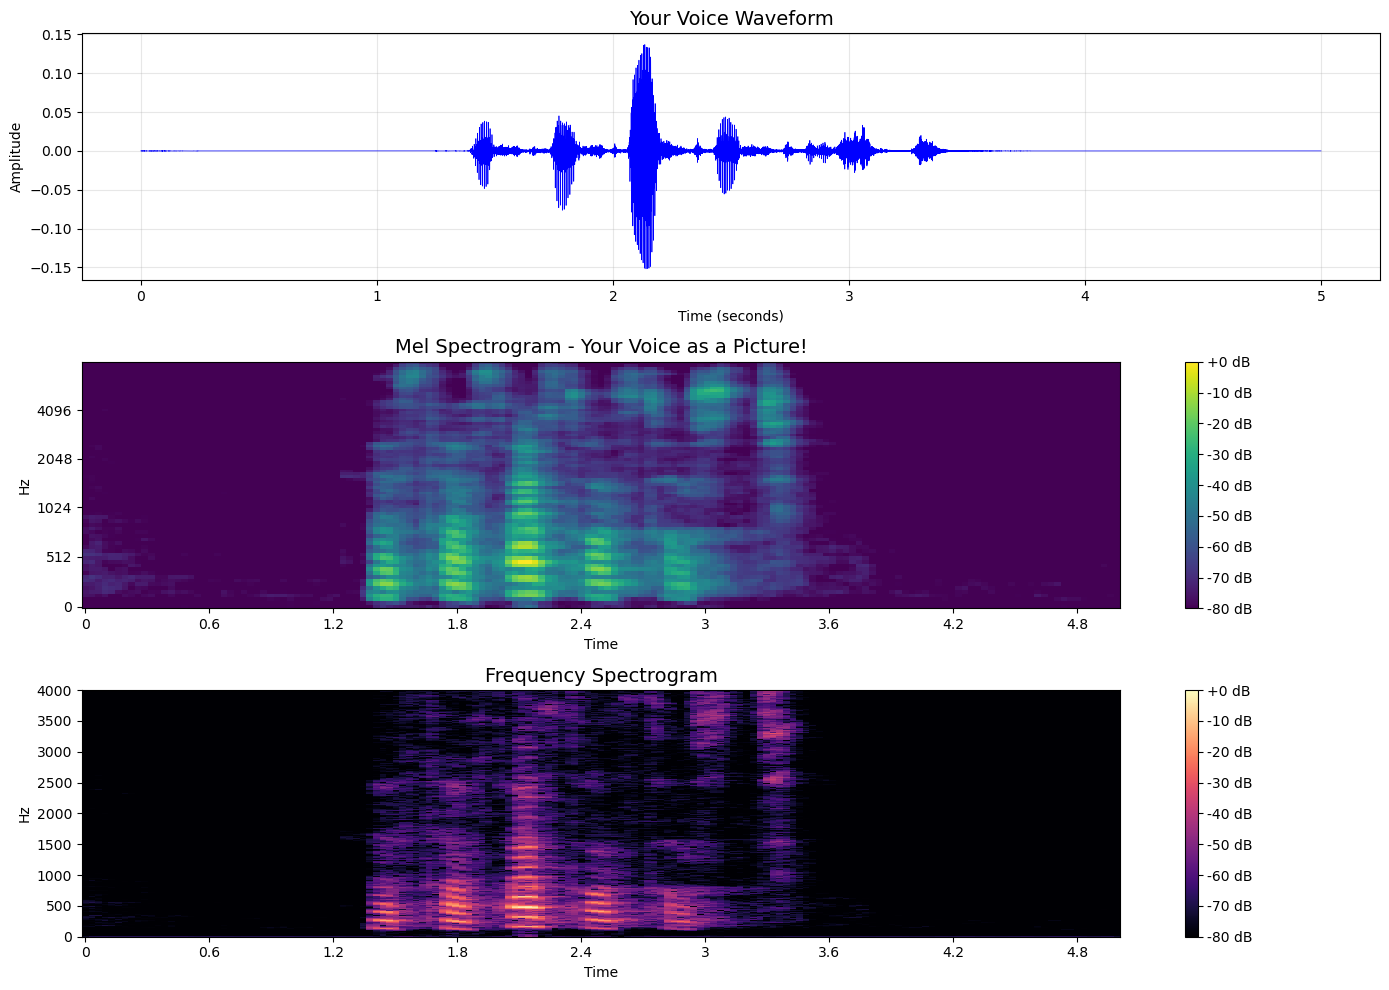

In [3]:
import sounddevice as sd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

duration = 5  # seconds
sample_rate = 16000

print(f"🎤 Recording for {duration} seconds... Speak now!")
audio = sd.rec(int(duration * sample_rate), 
               samplerate=sample_rate, 
               channels=1, 
               dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")


print("This is your voice")
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

time = np.linspace(0, len(audio) / sample_rate, len(audio))
axes[0].plot(time, audio, color='blue', linewidth=0.5)
axes[0].set_title('Your Voice Waveform', fontsize=14)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

print("Mel Spectogram") 
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=80)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_spec_db, sr=sample_rate, 
                                x_axis='time', y_axis='mel', 
                                ax=axes[1], cmap='viridis')
axes[1].set_title('Mel Spectrogram - Your Voice as a Picture!', fontsize=14)
plt.colorbar(img, ax=axes[1], format='%+2.0f dB')

print("Spectogram") 
D = librosa.stft(audio)
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img2 = librosa.display.specshow(D_db, sr=sample_rate, 
                                 x_axis='time', y_axis='hz', 
                                 ax=axes[2], cmap='magma')
axes[2].set_title('Frequency Spectrogram', fontsize=14)
axes[2].set_ylim(0, 4000)  # Focus on speech frequencies
plt.colorbar(img2, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [4]:
import scipy.io.wavfile as wavfile
from openai import OpenAI
import io
import os
from IPython.display import Audio, display
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

duration = 5  # seconds
sample_rate = 16000

print(f"🎤 Recording for {duration} seconds... Speak now!")
audio = sd.rec(int(duration * sample_rate), 
               samplerate=sample_rate, 
               channels=1, 
               dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")


audio_int16 = np.int16(audio * 32767)

# Create in-memory WAV file
buffer = io.BytesIO()
wavfile.write(buffer, sample_rate, audio_int16)
buffer.seek(0)
buffer.name = "recording.wav"  # Whisper needs a filename

# Transcribe with Whisper
print("🤖 Transcribing with Whisper...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer
)

print("\n📝 Transcription:")
print("-" * 40)
print(transcript.text)

🎤 Recording for 5 seconds... Speak now!
✅ Recording complete!
🤖 Transcribing with Whisper...

📝 Transcription:
----------------------------------------
test, test, test, I'm testing my test, test, test, test, test.


In [5]:
import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wavfile
from openai import OpenAI
import io
from IPython.display import Audio, display, Markdown

#client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Display a 30-second reading text
reading_text = """
**Read this text aloud (about 30 seconds):**

The researchers' analyses of the wind farm data showed variable wind patterns. The project 
lead will lead the team through complex permit processes. They must present the present 
findings to investors. The 3 million contract includes clauses for force majeure 
events. Dr. García-Smith's team discovered that the enzyme's pH of 7.2 was optimal. The 
AI learned to differentiate between "read" (present) and "read" (past), processing live 
feeds versus archived content. The baroque bass player stood close to the entrance, too 
close to record properly.
"""

display(Markdown(reading_text))

# Record for 30 seconds
duration = 45
sample_rate = 16000

print(f"\n🎤 Recording for {duration} seconds... Start reading now!")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")

display(Audio(audio, rate=sample_rate))


# Prepare audio
audio_int16 = np.int16(audio * 32767)
buffer = io.BytesIO()
wavfile.write(buffer, sample_rate, audio_int16)
buffer.seek(0)
buffer.name = "recording.wav"

# Transcribe without context prompt
print("🤖 Transcribing without context...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer,
)

print("\n📝 Transcription:")
print("-" * 40)
print(transcript.text)


**Read this text aloud (about 30 seconds):**

The researchers' analyses of the wind farm data showed variable wind patterns. The project 
lead will lead the team through complex permit processes. They must present the present 
findings to investors. The 3 million contract includes clauses for force majeure 
events. Dr. García-Smith's team discovered that the enzyme's pH of 7.2 was optimal. The 
AI learned to differentiate between "read" (present) and "read" (past), processing live 
feeds versus archived content. The baroque bass player stood close to the entrance, too 
close to record properly.



🎤 Recording for 45 seconds... Start reading now!
✅ Recording complete!


🤖 Transcribing without context...

📝 Transcription:
----------------------------------------
The researchers' analysis of the wind farm data showed variable patterns. The project lead will lead the team through complex remit processes. They must present the present findings to investors. The 3 million contract includes clauses for force majeure events. Dr. Garcia-Smith's team discovered that the enzyme pH of 7.2 was optimal. The AI learned to differentiate between read present and read past. Processing live feeds versus archived content, the Baroque pile of bass players stood close to the entrance, too close to record properly.


In [6]:
# Transcribe with context prompt
print("🤖 Transcribing with context...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer,
    prompt = "heteronyms, homographs, lead metal, wind turbine, present tense, past tense read, pH levels, enzyme, García-Smith, force majeure, baroque, bass instrument, differentiate")

print("\n📝 Transcription:")
print("-" * 40)
print(transcript.text)

🤖 Transcribing with context...

📝 Transcription:
----------------------------------------
The researchers' analysis of the wind farm data showed variable patterns. The project lead will lead the team through complex remit processes. They must present the present findings to investors. The 3 million contract includes clauses for force majeure events. Dr. García-Smith's team discovered that the enzyme pH of 7.2 was optimal. The AI learned to differentiate between read present and read past, processing live feeds versus archived content. The baroque pile of bass players stood close to the entrance, too close to record properly.


In [7]:
import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wavfile
from openai import OpenAI
import io

#client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Record longer audio
duration = 15  # seconds total
sample_rate = 16000
chunk_duration = 5  # seconds per chunk

print(f"🎤 Recording for {duration} seconds... Speak continuously!")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")

display(Audio(audio, rate=sample_rate))


# Split audio into chunks
chunk_size = chunk_duration * sample_rate
chunks = [audio[i:i+chunk_size] for i in range(0, len(audio), chunk_size)]

print(f"\n🔪 Split into {len(chunks)} chunks")

# Transcribe each chunk
all_transcripts = []

for i, chunk in enumerate(chunks):
    print(f"\n🤖 Transcribing chunk {i+1}/{len(chunks)}...")
    
    # Prepare chunk buffer
    chunk_int16 = np.int16(chunk * 32767)
    buffer = io.BytesIO()
    wavfile.write(buffer, sample_rate, chunk_int16)
    buffer.seek(0)
    buffer.name = f"chunk_{i}.wav"
    
    # Transcribe
    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=buffer
    )
    
    all_transcripts.append(transcript.text)
    print(f"Chunk {i+1}: {transcript.text}")

# Combine all transcripts
print("\n📝 Complete Transcription:")
print("-" * 40)
full_text = " ".join(all_transcripts)
print(full_text)

🎤 Recording for 15 seconds... Speak continuously!
✅ Recording complete!



🔪 Split into 3 chunks

🤖 Transcribing chunk 1/3...
Chunk 1: Okay, so I have to...

🤖 Transcribing chunk 2/3...
Chunk 2: I'll continuously speak for 15 seconds so that I can parse my...

🤖 Transcribing chunk 3/3...
Chunk 3: data using chunks I think is the word, anyways

📝 Complete Transcription:
----------------------------------------
Okay, so I have to... I'll continuously speak for 15 seconds so that I can parse my... data using chunks I think is the word, anyways


In [8]:
import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wavfile
from openai import OpenAI
import io
from IPython.display import Audio, display

#client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

duration = 10  # seconds
sample_rate = 16000

print(f"🎤 Recording for {duration} seconds... Speak with pauses!")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")

# Play back
display(Audio(audio, rate=sample_rate))

# Prepare audio
audio_int16 = np.int16(audio * 32767)
buffer = io.BytesIO()
wavfile.write(buffer, sample_rate, audio_int16)
buffer.seek(0)
buffer.name = "recording.wav"

# Get detailed transcription with timestamps
print("\n🤖 Transcribing with timestamps...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer,
    response_format="verbose_json",
    timestamp_granularities=["segment", "word"]  # Get both segment and word timestamps
)

# Display formatted timestamps
print("\n📝 Transcription with timestamps:")
print("-" * 40)

# Show segments with timestamps
if hasattr(transcript, 'segments'):
    for segment in transcript.segments:
        start = segment.start
        end = segment.end
        text = segment.text
        print(f"\n[{start:.2f}s - {end:.2f}s]")
        print(f"  {text}")

# Show word-level timestamps if available
if hasattr(transcript, 'words'):
    print("\n🔤 Word-level timing:")
    print("-" * 40)
    for word in transcript.words:
        word_text = word.word
        start = word.start
        end = word.end
        print(f"{word_text:15} [{start:.2f}s - {end:.2f}s]")

# Full text and metadata
print("\n📄 Full text:")
print(transcript.text)

print(f"\n🌍 Language detected: {transcript.language}")
print(f"⏱️ Total duration: {transcript.duration:.2f}s")

🎤 Recording for 10 seconds... Speak with pauses!
✅ Recording complete!



🤖 Transcribing with timestamps...

📝 Transcription with timestamps:
----------------------------------------

[2.46s - 9.58s]
   Okay, this time I'll speak with pauses for 10 seconds.

🔤 Word-level timing:
----------------------------------------
Okay            [2.46s - 3.42s]
this            [3.42s - 3.70s]
time            [3.70s - 4.20s]
I'll            [4.20s - 5.84s]
speak           [5.84s - 6.12s]
with            [6.12s - 6.54s]
pauses          [6.54s - 7.02s]
for             [7.02s - 8.72s]
10              [8.72s - 9.04s]
seconds         [9.04s - 9.58s]

📄 Full text:
Okay, this time I'll speak with pauses for 10 seconds.

🌍 Language detected: english
⏱️ Total duration: 10.00s


###Start of Lab Exercise

In [9]:
#Basic transcirption of Arthur the Rat
from openai import OpenAI

client = OpenAI()
audio_file= open("Arthur.mp3", "rb")

transcription = client.audio.transcriptions.create(
    model="gpt-4o-transcribe", 
    file=audio_file
)

print(transcription.text)

The story of Arthur the Rat. Once upon a time there was a young rat who couldn't make up his mind. Whenever the other rats asked him if he would like to come out hunting with them, he would answer in a hoarse voice, I don't know. And when they said, would you rather stay inside, he would say yes or no, either. He'd always shake making a choice. One fine day his Aunt Josephine said to him, now look here, no one will ever care for you if you carry on like this. You have no more mind of your own than a greasy old bladed grass. The young rat coughed and looked quiet as usual but said nothing. Don't you think so, said his Aunt, stamping her foot, for she couldn't bear to see the young rat so cold-blooded. I don't know was all he ever answered. And then he walked off to think for an hour or more whether he would stay in his hole in the ground or go out into the loft. One night the rats heard a loud noise in the loft. It was a very dreary old place. The roof let the rain come down, come washi

In [ ]:
#Transcription of Arthur the Rat with prompting for context
from openai import OpenAI

client = OpenAI()
audio_file = open("Arthur.mp3", "rb")

transcription = client.audio.transcriptions.create(
  model="gpt-4o-transcribe", 
  file=audio_file, 
  response_format="text",
  prompt="The following is a story for children about a rat named Arthur. Please transcribe the audio and provide a summary of the story, highlighting key events and characters."
)

print(transcription)
#better punctuation than the previous transcription, reads easier but otherwise identical.


The story of Arthur the Rat. Once upon a time, there was a young rat who couldn't make up his mind. Whenever the other rats asked him if he would like to come out hunting with them, he would answer in a hoarse voice, I don't know. And when they said, would you rather stay inside, he would say yes or no, either. He'd always shake, making a choice. One fine day, his aunt Josephine said to him, now look here, no one will ever care for you if you carry on like this. You have no more mind of your own than a greasy old bladed grass. The young rat coughed and looked quiet as usual, but said nothing. Don't you think so, said his aunt, stamping her foot, for she couldn't bear to see the young rat so cold-blooded. I don't know, was all he ever answered. And then he walked off to think for an hour or more, whether he would stay in his hole in the ground or go out into the loft. One night the rats heard a loud noise in the loft. It was a very dreary old place. The roof let the rain come down, come

In [21]:
from openai import OpenAI

import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wavfile
import librosa
import io

#client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Record longer audio
# duration = 15  # seconds total
sample_rate = 16000
chunk_duration = 15  # seconds per chunk

# Load the MP3 file and resample to 16 kHz
print("Loading Arthur.mp3 and converting to waveform...")
audio, sr = librosa.load("Arthur.mp3", sr=sample_rate, mono=True)
audio = np.asarray(audio, dtype=np.float32)

# Split audio into chunks
chunk_size = chunk_duration * sample_rate
chunks = [audio[i:i + chunk_size] for i in range(0, len(audio), chunk_size)]

print(f"\n🔪 Split into {len(chunks)} chunks")

# Transcribe each chunk
all_transcripts = []

for i, chunk in enumerate(chunks):
    print(f"\n🤖 Transcribing chunk {i+1}/{len(chunks)}...")
    
    # Prepare chunk buffer
    chunk_int16 = np.int16(chunk * 32767)
    buffer = io.BytesIO()
    wavfile.write(buffer, sample_rate, chunk_int16)
    buffer.seek(0)
    buffer.name = f"chunk_{i}.wav"
    
    # Transcribe with timestamps
    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=buffer,
        response_format="verbose_json",
        timestamp_granularities=["segment", "word"]
    )
    
    # Print chunk-level transcription with timestamps
    print(f"Chunk {i+1} transcription:")
    if hasattr(transcript, 'segments'):
        for segment in transcript.segments:
            print(f"[{segment.start:.2f}s - {segment.end:.2f}s] {segment.text}")
    else:
        print(transcript.text)

    # Optional word-level timing
    if hasattr(transcript, 'words'):
        print("\n  Word timestamps:")
        for word in transcript.words:
            print(f"    {word.word:15} [{word.start:.2f}s - {word.end:.2f}s]")

    all_transcripts.append(transcript.text)

# Combine all transcripts
print("\n📝 Complete Transcription:")
print("-" * 40)
full_text = " ".join(all_transcripts)
print(full_text)


Loading Arthur.mp3 and converting to waveform...

🔪 Split into 16 chunks

🤖 Transcribing chunk 1/16...
Chunk 1 transcription:
[0.00s - 6.30s]  The story of Arthur the Rat. Once upon a time there was a young rat who couldn't
[6.30s - 11.66s]  make up his mind. Whenever the other rat says to him if he would like to come out
[11.66s - 14.98s]  hunting with them, he would answer in a hoarse voice.

  Word timestamps:
    The             [0.00s - 0.98s]
    story           [0.98s - 1.44s]
    of              [1.44s - 1.98s]
    Arthur          [1.98s - 2.10s]
    the             [2.10s - 2.70s]
    Rat             [2.70s - 2.70s]
    Once            [3.32s - 3.38s]
    upon            [3.38s - 3.70s]
    a               [3.70s - 4.14s]
    time            [4.14s - 4.40s]
    there           [4.40s - 4.70s]
    was             [4.70s - 4.92s]
    a               [4.92s - 5.14s]
    young           [5.14s - 5.40s]
    rat             [5.40s - 5.76s]
    who             [5.76s - 6.16s]
    cou

In [24]:
from openai import OpenAI

import io
import json
import librosa
import numpy as np
import scipy.io.wavfile as wavfile

# client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
client = OpenAI()  # Automatically loads from environment variable

sample_rate = 16000
chunk_duration = 15  # seconds per chunk

print("Loading Arthur.mp3 and converting to waveform...")
audio, sr = librosa.load("Arthur.mp3", sr=sample_rate, mono=True)
audio = np.asarray(audio, dtype=np.float32)

chunk_size = chunk_duration * sample_rate
chunks = [audio[i : i + chunk_size] for i in range(0, len(audio), chunk_size)]

print(f"\n🔪 Split into {len(chunks)} chunks")

# --- MODIFICATION START: Containers for Master Export Data ---
all_transcripts = []
master_segments = []  # Will hold all segments adjusted with cumulative time
master_words = []  # Will hold all words adjusted with cumulative time
# -------------------------------------------------------------

for i, chunk in enumerate(chunks):
    print(f"\n🤖 Transcribing chunk {i+1}/{len(chunks)}...")

    chunk_int16 = np.int16(chunk * 32767)
    buffer = io.BytesIO()
    wavfile.write(buffer, sample_rate, chunk_int16)
    buffer.seek(0)
    buffer.name = f"chunk_{i}.wav"

    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=buffer,
        response_format="verbose_json",
        timestamp_granularities=["segment", "word"],
    )

    # --- MODIFICATION START: Calculate Time Offset for this Chunk ---
    time_offset = i * chunk_duration
    # -----------------------------------------------------------------

    print(f"Chunk {i+1} transcription:")
    if hasattr(transcript, "segments") and transcript.segments:
        for segment in transcript.segments:
            # Shift segment times so they align linearly in the final file
            adjusted_start = segment.start + time_offset
            adjusted_end = segment.end + time_offset

            print(f"[{adjusted_start:.2f}s - {adjusted_end:.2f}s] {segment.text}")

            # Save to master collection
            master_segments.append(
                {
                    "id": len(master_segments),
                    "start": adjusted_start,
                    "end": adjusted_end,
                    "text": segment.text.strip(),
                }
            )
    else:
        print(transcript.text)

    if hasattr(transcript, "words") and transcript.words:
        print("\n  Word timestamps:")
        for word in transcript.words:
            adjusted_word_start = word.start + time_offset
            adjusted_word_end = word.end + time_offset

            print(
                f"    {word.word:15} [{adjusted_word_start:.2f}s - {adjusted_word_end:.2f}s]"
            )

            master_words.append(
                {
                    "word": word.word,
                    "start": adjusted_word_start,
                    "end": adjusted_word_end,
                }
            )

    all_transcripts.append(transcript.text)

print("\n📝 Complete Transcription:")
print("-" * 40)
full_text = " ".join(all_transcripts)
print(full_text)


# =====================================================================
# --- MODIFICATION START: EXPORT PROCESSORS AND FILE CREATION ---
# =====================================================================


# Helper function to convert seconds to SRT time format (HH:MM:SS,mmm)
def format_srt_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    milliseconds = int(round((seconds % 1) * 1000))
    return f"{hours:02d}:{minutes:02d}:{secs:02d},{milliseconds:03d}"


# Helper function to convert seconds to plain text timestamp format [HH:MM:SS]
def format_txt_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"[{hours:02d}:{minutes:02d}:{secs:02d}]"


print("\n💾 Generating and exporting output files...")

# 1. Export JSON (combines both full text and adjusted chronological segments/words)
master_json_data = {
    "text": full_text,
    "segments": master_segments,
    "words": master_words,
}
with open("transcription.json", "w", encoding="utf-8") as f:
    json.dump(master_json_data, f, indent=4, ensure_ascii=False)
print(" -> Saved: transcription.json")

# 2. Export TXT with Timestamps
with open("transcription.txt", "w", encoding="utf-8") as f:
    for seg in master_segments:
        timestamp = format_txt_time(seg["start"])
        f.write(f"{timestamp} {seg['text']}\n")
print(" -> Saved: transcription.txt")

# 3. Export SRT Subtitle File
with open("transcription.srt", "w", encoding="utf-8") as f:
    for index, seg in enumerate(master_segments):
        f.write(f"{index + 1}\n")
        start_srt = format_srt_time(seg["start"])
        end_srt = format_srt_time(seg["end"])
        f.write(f"{start_srt} --> {end_srt}\n")
        f.write(f"{seg['text']}\n\n")
print(" -> Saved: transcription.srt")

print("\n🎉 All 3 file formats exported with stitched timestamps successfully!")


Loading Arthur.mp3 and converting to waveform...

🔪 Split into 16 chunks

🤖 Transcribing chunk 1/16...
Chunk 1 transcription:
[0.00s - 6.30s]  The story of Arthur the Rat. Once upon a time there was a young rat who couldn't
[6.30s - 11.66s]  make up his mind. Whenever the other rat says to him if he would like to come out
[11.66s - 14.98s]  hunting with them, he would answer in a hoarse voice.

  Word timestamps:
    The             [0.00s - 0.98s]
    story           [0.98s - 1.44s]
    of              [1.44s - 1.98s]
    Arthur          [1.98s - 2.10s]
    the             [2.10s - 2.70s]
    Rat             [2.70s - 2.70s]
    Once            [3.32s - 3.38s]
    upon            [3.38s - 3.70s]
    a               [3.70s - 4.14s]
    time            [4.14s - 4.40s]
    there           [4.40s - 4.70s]
    was             [4.70s - 4.92s]
    a               [4.92s - 5.14s]
    young           [5.14s - 5.40s]
    rat             [5.40s - 5.76s]
    who             [5.76s - 6.16s]
    cou

###Brief Report
- Difference between prompted and unprompted: These were virtually identical; however, the prompted version had a better handling of punctuation as it related to the reading of a story. If I were to purchase this output as a book, I would be able to read it better as a story teller with the punctuation and therefore closer to the original audio.
- Benefits of chunking for long audio:
    - Since Whisper is restricted to 25mb per request, chunking allows for the requests to never cross that threshhold and cause the server to reject the request.
    - In a similar vein, it prevents memory errors that could crash the application.
    - Network errors can resume at the last chunk rather than at the start.
    - Parallel processing of chunks can make the converter faster.
Reccomendation for Improving Accuracy:
    - I could pass the privious chunk into the next chunk for improved context and guidance.
    - I could make my chunk limit bigger to have less errors between chunks.
    - I could introduce a glossary if this were more technical audio.
    - I could reduce noise by pre-processing the audio if needed.
    - In general the transcription was near flawless.